<a href="https://colab.research.google.com/github/mahalakshmi218/VRSU/blob/main/VRSU_ImageSegmentationProgram3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving img1.jpg to img1 (2).jpg


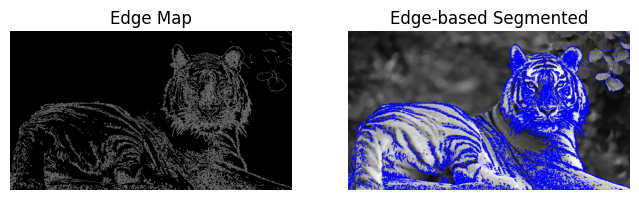

In [ ]:
#program 3
#edge detection for image segmentation

import cv2
import matplotlib.pyplot as plt
from google.colab import files


uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# read image in grayscale
img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)

if img is None:
    raise ValueError("Failed to load image!")

# step-1 edge detection
edges = cv2.Canny(img, 100, 200)

# step-2 find contours (segmentation)
# syntax- findcontours(image, mode, method)
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# convert to color to draw contours
segmented = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# draw contours
cv2.drawContours(segmented, contours, -1, (0, 0,255), 2)

# display
plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
plt.title("Edge Map")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Edge-based Segmented")
plt.imshow(segmented, cmap='gray')
plt.axis('off')

plt.show()

Saving zebraimg.jpg to zebraimg.jpg


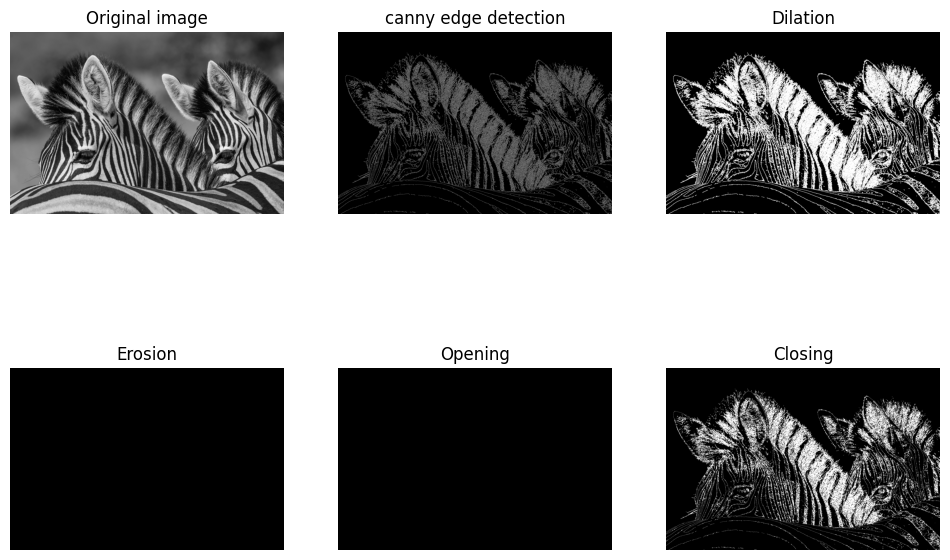

In [ ]:
#morphological operations- process images based on shape and structure
import cv2
import numpy as np
import matplotlib.pyplot as plt

# step-1 read the image
from google.colab import files

uploaded = files.upload()

image_path= list(uploaded.keys())[0]

img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)

# step-2 edge detection (canny)
edges= cv2.Canny(img, 100, 200)

# step-3 create structuring element
kernel = np.ones((3, 3), np.uint8)

# step-4 morphological operations
# dilation- thickens edges
dilated = cv2.dilate(edges, kernel, iterations=1)

# Erosion - thins edges/ removes noise
eroded = cv2.erode(edges, kernel, iterations=1)

# Opening- erosion followes by dilation
opening = cv2.morphologyEx(edges, cv2.MORPH_OPEN, kernel)

# Closing- dilation follows by erosion

closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# step-5 display results
plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.title("Original image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2,3,2)
plt.title("canny edge detection")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Dilation")
plt.imshow(dilated, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Erosion")
plt.imshow(eroded, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Opening")
plt.imshow(opening, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Closing")
plt.imshow(closing, cmap='gray')
plt.axis('off')

plt.show()
